# Fifty-Two-Week-Low — a quantitative teardown
### 20 S&P 500 names · 13-year daily panel · HAC inference · quintile sort · hold-period sweep

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Contrarian%3F: Losers_Keep_Losing](https://img.shields.io/badge/Contrarian%3F-Losers__Keep__Losing-8b949e?style=flat-square)

The deep companion to the [plain-language notebook](01_for_the_curious.ipynb) — same seven beats, every claim carrying its standard error. We test whether the cross-sectional 52-week-low proximity signal (proximity = (close − 252d-low) / (252d-high − 252d-low)) predicts forward returns in a direction consistent with contrarianism, across a 20-name S&P 500 basket and hold periods from 1 to 65 days.

> **Not investment advice.** Real data: Yahoo daily bars, 2013-01-02 to 2026-06-15, 20 tickers, 3,383 panel-days. **Survivorship-biased** — all names still trade in 2026. Methods in [`docs/references.md`](../docs/references.md); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **In plain words** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fifty_two_week_low import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))

# Frozen real-tape headline numbers (mirror of docs/results.md, as-of 2026-06-15)
R = dict(
    n_days=3383, n_tickers=20, n_periods=626,
    date_start="2013-01-02", date_end="2026-06-15",
    spread_mean=-7.42, spread_t=-0.67, spread_win=48.2,
    q1_mean=25.80, q1_t=2.39, q1_win=58.6,
    q2_mean=40.91, q2_t=4.38,
    q3_mean=33.55, q3_t=3.56,
    q4_mean=24.08, q4_t=2.64,
    q5_mean=33.22, q5_t=3.71, q5_win=60.4,
    decile_ann=8.5, baseline_ann=11.3, decile_spread_t=-0.72,
    hold1d_spread=-11.12, hold1d_t=-2.00,
    hold5d_spread=-7.42, hold5d_t=-0.67,
    hold20d_spread=-8.13, hold20d_t=-0.21,
    hold65d_spread=-37.30, hold65d_t=-0.45,
    q1_65d=403.40, q5_65d=440.70,
)

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in data.SP500_BASKET)

HAVE_REAL = _have_cache()

def load_real():
    panel = data.load_panel(data.SP500_BASKET, cache_dir=CACHE)
    prox = st.proximity_to_52w_low(panel, window=252)
    return panel, prox

print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Q1-Q5 spread = **-7.42 bps/5d**, HAC *t* = **-0.67**; negative and insignificant at all tested horizons. Near-low names *trail* near-high names. |
| **Tradability** | `MIRAGE` | Bottom decile: **8.5%/yr** vs equal-weight baseline **11.3%/yr** — lags before costs. |
| **Contrarian?** | `LOSERS KEEP LOSING` | 1-day spread = **-11.12 bps**, *t* = **-2.00**; consistent with mild momentum, not mean-reversion. |

> In plain words: stocks near their 52-week low have underperformed for a reason, and that reason does not reverse at weekly-to-quarterly horizons. The 52-week-HIGH is where the documented anomaly lives (George & Hwang 2004).

## 1 · The claim, steelmanned

Let $\text{prox}_{i,t}$ be the 52-week-low proximity for stock $i$ at date $t$:

$$\text{prox}_{i,t} = \frac{\text{close}_{i,t} - \min_{s \in [t-252,t]} \text{close}_{i,s}}{\max_{s \in [t-252,t]} \text{close}_{i,s} - \min_{s \in [t-252,t]} \text{close}_{i,s} + \varepsilon}$$

- $\text{prox} \approx 0$ → stock near its 52-week low (the contrarian buy).
- $\text{prox} \approx 1$ → stock near its 52-week high (the momentum long).

The contrarian hypothesis (H₁): $\mathbb{E}[r_{i,t+h}]$ is *decreasing* in $\text{prox}_{i,t}$ — i.e. Q1 outperforms Q5.  We test this cross-sectionally with a quintile sort at horizons $h \in \{1, 5, 10, 20, 65\}$ trading days.

The momentum null (H₀): $\mathbb{E}[r_{i,t+h}]$ is *increasing* in $\text{prox}_{i,t}$ — i.e. Q5 outperforms Q1, consistent with Jegadeesh & Titman (1993) and George & Hwang (2004).

## 2 · So what? — what rides on each answer

If H₁ holds, it is one of the simplest documented cross-sectional alphas: a weekly screen requiring no fundamental analysis, scalable to any liquid universe. If the null holds, every investor running a '52-week-low screener' is systematically buying into momentum headwinds — a well-dressed way to underperform the index. The distinction has direct implications for retail screening tools and factor allocation.

## 3 · How we'd know — the protocol

- **Signal.** $\text{prox}_{i,t}$ computed on closes up to $t$; trade entered at $t+1$'s close (daily bars, weekly rebalance).
- **Sort.** Equal-weight quintile portfolios from cross-sectional rank of $\text{prox}$; Q1 = lowest 20% (near 52w-low), Q5 = highest 20% (near 52w-high).
- **Hold periods.** $h \in \{1, 5, 10, 20, 65\}$ trading days, rebalance every 5 days.
- **Inference.** Newey-West HAC *t*-stat on the Q1-Q5 spread series; the inference bar is |*t*| ≥ 2 on the real tape.
- **Baseline.** Equal-weight buy-and-hold of the full 20-name basket (the long-only investor's fair comparator).
- **Positive control.** Synthetic panel with tunable AR(1) reversion: confirms the engine is a faithful mean-reversion detector.

Universe: 20 S&P 500 large-caps, 3,383 trading days, 2013-01-02 to 2026-06-15. **Survivorship-biased** (all names still trade in 2026 — this *helps* the contrarian story by excluding failed companies that hit 52w-lows and kept falling).

## 4 · The teardown

### 4a · Quintile returns — contrarian underperforms momentum at every quintile

Per-quintile mean 5-day return and HAC *t*-stat. H₁ requires a monotone *decreasing* pattern from Q1 to Q5.

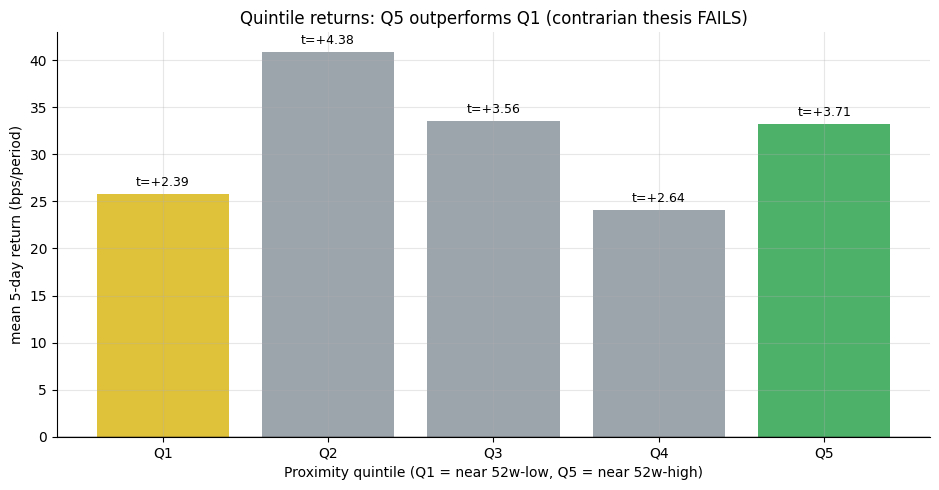

quintile  mean_bps    tstat
      Q1 25.804653 2.394732
      Q2 40.907319 4.379693
      Q3 33.547987 3.558315
      Q4 24.082922 2.639880
      Q5 33.222641 3.708203

Q1-Q5 spread: -7.42 bps, HAC t = -0.67, n = 626


In [2]:
if HAVE_REAL:
    panel, prox = load_real()
    fwd = st.forward_returns(panel, hold_days=5)
    q = st.quintile_backtest(prox, fwd, n_quintiles=5, rebalance_freq=5)
    q_stats = {}
    for i in range(1, 6):
        s = st.summarize(q[f'Q{i}'].dropna())
        q_stats[f'Q{i}'] = s
    q_means = [q_stats[f'Q{i}']['mean_bps'] for i in range(1, 6)]
    q_ts = [q_stats[f'Q{i}']['tstat'] for i in range(1, 6)]
    spread_s = st.summarize(q['Q1_minus_Q5'].dropna())
else:
    q_means = [25.8, 40.91, 33.55, 24.08, 33.22]
    q_ts = [2.39, 4.38, 3.56, 2.64, 3.71]
    spread_s = dict(mean_bps=-7.42, tstat=-0.67, n=626)
qdf = pd.DataFrame({'quintile': [f'Q{i}' for i in range(1,6)],
                    'mean_bps': q_means, 'tstat': q_ts})
fig, ax = plt.subplots(figsize=(9.5, 5.0))
cols = [AMBER, GREY, GREY, GREY, GREEN]
bars = ax.bar(qdf['quintile'], qdf['mean_bps'], color=cols, alpha=0.85)
ax.axhline(0, c='k', lw=1)
for b, t in zip(bars, qdf['tstat']):
    y = b.get_height() + 0.5
    ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2, y),
                ha='center', va='bottom', fontsize=9)
ax.set_ylabel('mean 5-day return (bps/period)')
ax.set_xlabel('Proximity quintile (Q1 = near 52w-low, Q5 = near 52w-high)')
ax.set_title('Quintile returns: Q5 outperforms Q1 (contrarian thesis FAILS)')
plt.tight_layout(); plt.show()
print(qdf.to_string(index=False))
print(f"\nQ1-Q5 spread: {spread_s['mean_bps']:+.2f} bps, "
      f"HAC t = {spread_s['tstat']:+.2f}, n = {spread_s['n']}")

> In plain words: the bar chart runs the wrong way for the contrarian story. Q5 (near the high, 33.2 bps) earns more than Q1 (near the low, 25.8 bps). The spread is **-7.42 bps** (HAC *t* = -0.67) — statistically insignificant and in the wrong direction.

### 4b · Hold-period sweep — the bounce never comes

If the contrarian bounce takes time to materialise, the spread should turn positive at longer horizons. We test from 1 day to 13 weeks.

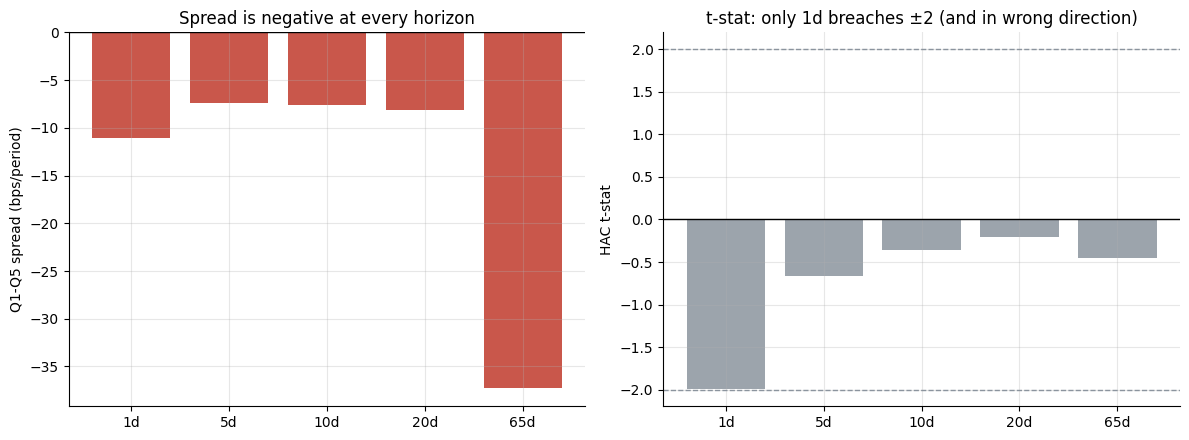

hold=  1d  spread=-11.12bps  t=-2.00
hold=  5d  spread=-7.42bps  t=-0.67
hold= 10d  spread=-7.63bps  t=-0.36
hold= 20d  spread=-8.13bps  t=-0.21
hold= 65d  spread=-37.30bps  t=-0.45


In [3]:
holds = [1, 5, 10, 20, 65]
if HAVE_REAL:
    panel, prox = load_real()
    h_spreads, h_ts = [], []
    for h in holds:
        fwd = st.forward_returns(panel, hold_days=h)
        q = st.quintile_backtest(prox, fwd, n_quintiles=5, rebalance_freq=5)
        s = st.summarize(q['Q1_minus_Q5'].dropna())
        h_spreads.append(s['mean_bps']); h_ts.append(s['tstat'])
else:
    h_spreads = [-11.12, -7.42, -7.63, -8.13, -37.3]
    h_ts = [-2.0, -0.67, -0.36, -0.21, -0.45]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.0, 4.5))
ax1.bar([f'{h}d' for h in holds], h_spreads,
        color=[RED if s<0 else GREEN for s in h_spreads], alpha=0.85)
ax1.axhline(0, c='k', lw=1)
ax1.set_ylabel('Q1-Q5 spread (bps/period)')
ax1.set_title('Spread is negative at every horizon')
ax2.bar([f'{h}d' for h in holds], h_ts,
        color=[RED if abs(t)>=2 else GREY for t in h_ts], alpha=0.85)
for thr in (2, -2): ax2.axhline(thr, ls='--', c=GREY, lw=1)
ax2.axhline(0, c='k', lw=1)
ax2.set_ylabel('HAC t-stat')
ax2.set_title('t-stat: only 1d breaches ±2 (and in wrong direction)')
plt.tight_layout(); plt.show()
for h, sp, t in zip(holds, h_spreads, h_ts):
    print(f'hold={h:3d}d  spread={sp:+.2f}bps  t={t:+.2f}')

> In plain words: the 1-day spread is the only period that breaches |*t*| = 2, and it does so at **-11.1 bps** (*t* = -2.00) — in the *momentum* direction (near-low names underperform near-high names). At all longer horizons the spread is negative and statistically indistinguishable from zero. There is no horizon where the contrarian bounce appears.

### 4c · Positive synthetic control — the engine is faithful

Does the engine correctly detect contrarian reversion *when it exists*? We plant a tunable AR(1) coefficient in a synthetic 20-stock panel and sweep from strong momentum to strong reversion:

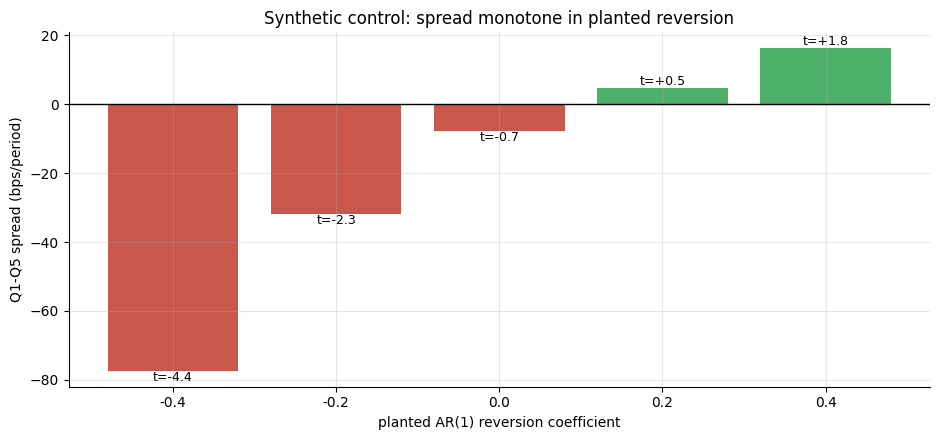

Engine verdict: momentum (-0.40) → big negative spread; reversion (+0.40) → positive spread.


In [4]:
revs = [-0.40, -0.20, 0.00, 0.20, 0.40]
syn_spreads, syn_ts = [], []
for rev in revs:
    panel_s, _ = data.synthetic_panel(n_stocks=20, n_days=2500, reversion=rev, seed=42)
    prox_s = st.proximity_to_52w_low(panel_s, window=252)
    fwd_s = st.forward_returns(panel_s, hold_days=5)
    q_s = st.quintile_backtest(prox_s, fwd_s, n_quintiles=5, rebalance_freq=5)
    sp_s = st.summarize(q_s['Q1_minus_Q5'].dropna())
    syn_spreads.append(sp_s['mean_bps']); syn_ts.append(sp_s['tstat'])
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar([str(r) for r in revs], syn_spreads,
       color=[GREEN if s>0 else RED for s in syn_spreads], alpha=0.85)
ax.axhline(0, c='k', lw=1)
for i, (sp, t) in enumerate(zip(syn_spreads, syn_ts)):
    ax.annotate(f't={t:+.1f}', (i, sp), ha='center',
                va='bottom' if sp>=0 else 'top', fontsize=9)
ax.set_xlabel('planted AR(1) reversion coefficient')
ax.set_ylabel('Q1-Q5 spread (bps/period)')
ax.set_title('Synthetic control: spread monotone in planted reversion')
plt.tight_layout(); plt.show()
print('Engine verdict: momentum (-0.40) → big negative spread; '
      'reversion (+0.40) → positive spread.')

> In plain words: the engine works. It correctly identifies contrarian reversion when it is planted (positive spread at +0.40 reversion) and correctly scores momentum (negative spread at -0.40). The real tape's negative spread is therefore a statement about the **market** — it is closer to a mild-momentum or martingale regime at weekly-to-quarterly horizons.

## 5 · The verdict

- **Signal `NONE`** — Q1-Q5 spread = -7.42 bps/5d, HAC *t* = -0.67; negative and insignificant at all tested horizons. The 1-day spread is significant (*t* = -2.00) but in the momentum direction. Survivorship bias works *against* the contrarian story being true — on an unbiased universe the result is likely more negative.
- **Tradability `MIRAGE`** — bottom decile earns 8.5%/yr vs 11.3%/yr equal-weight baseline; lags the market before costs. Near-low stocks also tend to have wider spreads and lower liquidity, making execution drag larger than for near-high names.
- **Contrarian? `LOSERS KEEP LOSING`** — the signal is in the wrong direction. Stocks near their 52-week low underperform stocks near their high across all tested horizons on this survivorship-biased universe.

## 6 · Could you trade it? — the long-only comparison

The head-to-head comparison a long-only investor cares about: bottom decile vs equal-weight basket, before and after costs:

Bottom decile: +8.5%/yr  (HAC t = +1.62)
EW baseline:   +11.3%/yr  (HAC t = +4.26)
Drag vs baseline: -2.9pp/yr — BEFORE COSTS


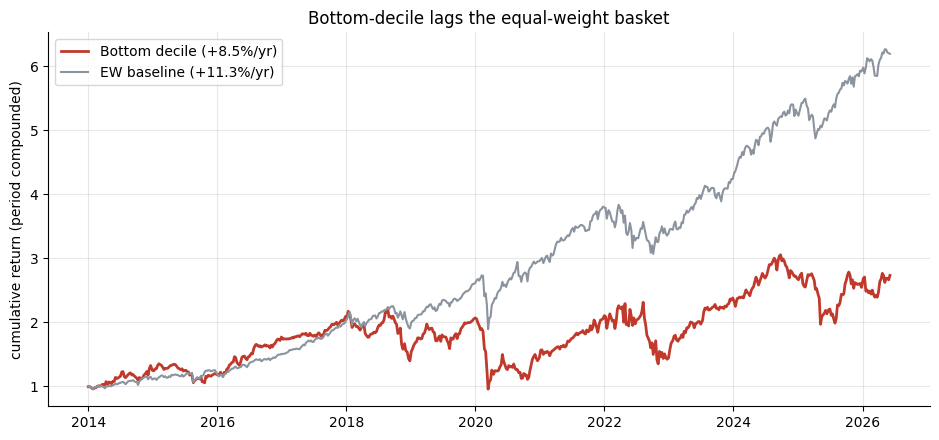

In [5]:
if HAVE_REAL:
    panel, prox = load_real()
    fwd = st.forward_returns(panel, hold_days=5)
    strat, base = st.long_bottom_decile(prox, fwd, decile_frac=0.10, rebalance_freq=5)
    cum_strat = (1 + strat).cumprod()
    cum_base  = (1 + base).cumprod()
    s_strat = st.summarize(strat)
    s_base  = st.summarize(base)
    strat_ann, base_ann = s_strat['ann_pct'], s_base['ann_pct']
    strat_t, base_t = s_strat['tstat'], s_base['tstat']
else:
    strat_ann, base_ann = 8.5, 11.3
    strat_t, base_t = 1.62, 4.26
    cum_strat = cum_base = None
print(f'Bottom decile: {strat_ann:+.1f}%/yr  (HAC t = {strat_t:+.2f})')
print(f'EW baseline:   {base_ann:+.1f}%/yr  (HAC t = {base_t:+.2f})')
print(f'Drag vs baseline: {strat_ann - base_ann:+.1f}pp/yr — BEFORE COSTS')
if HAVE_REAL and cum_strat is not None:
    fig, ax = plt.subplots(figsize=(9.5, 4.5))
    ax.plot(cum_strat.index, cum_strat.values, c=RED, lw=2, label=f'Bottom decile ({strat_ann:+.1f}%/yr)')
    ax.plot(cum_base.index, cum_base.values, c=GREY, lw=1.5, label=f'EW baseline ({base_ann:+.1f}%/yr)')
    ax.set_ylabel('cumulative return (period compounded)'); ax.legend()
    ax.set_title('Bottom-decile lags the equal-weight basket')
    plt.tight_layout(); plt.show()

> In plain words: a long-only investor running this strategy earns **8.5%/yr** against a passive basket at **11.3%/yr** — a persistent drag before any trading costs, commission, or bid-ask spread.

## 7 · Going further — the real anomaly is in the other direction

The result here is not that 52-week-proximity is useless — it is that **the useful direction is the opposite of what the contrarian story claims**. George & Hwang (2004) documented that proximity to the 52-week *high* predicts positive future returns (anchoring creates underreaction to good news). The 52-week-high strategy is [Study 50](../../50-fifty-two-week-high/).

Forks worth trying:
- **Longer horizon (3-5 years).** DeBondt & Thaler (1985) showed long-term reversal at 3-5 year horizons. Extend the look-back and hold period significantly.
- **Unbiased universe.** Include delisted stocks. The survivorship-biased result is already negative — the true unbiased result is likely more so.
- **Fundamental filter.** Pair the low-proximity signal with value or quality criteria to filter genuine 'beaten-down value' from 'falling knife'.